# EDA 05: Gene Fusions

## Purpose

A gene fusion happens when pieces from two different genes become joined. This can create an unusual RNA message and sometimes a new protein that drives cancer. A famous example is `EML4--ALK` in some lung cancers. However, many detected fusions are passengers, technical artefacts, or events with no known functional effect.

This notebook studies filtered fusion calls, their read support, breakpoints, recurrence, lineage context, and the model-pair summary used by the dashboard. Fusion calls are direct evidence that two named genes were observed together in a model, but they are not automatic proof that the fusion is functional or clinically important.

## Questions

1. Does every fusion call map to a valid model with a fusion assay?
2. How many calls and distinct gene pairs occur per model?
3. What do read support, FFPM, splice type, and anchor support tell us about technical confidence?
4. Which pairs recur across models and lineages?
5. What physical information is available about the breakpoints, and what is missing?
6. Can a user-entered pair be retrieved in either gene order without creating a hidden score?

## Considerations carried forward

- Use `model_id` as the model join key and a canonical unordered gene-pair ID for pair lookup.
- Define fusion absence only in models with `has_fusion_assay=1`.
- Preserve read counts, FFPM, splice type, breakpoints, anchor support, orientation, and annotations as visible evidence.
- Treat low-support calls as review candidates, not automatic biological zeros.
- Report recurrence with the assayed-model denominator and cancer lineage.
- Do not infer reading frame or retained protein function when those columns are absent from this 24Q4 table.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid', context='notebook')

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'depmap_24Q4' / 'architecture' / 'model_master.csv').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repository.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA = PROJECT_ROOT / 'data' / 'depmap_24Q4'

PATHS = {
    'master': DATA / 'architecture' / 'model_master.csv',
    'fusion_calls': DATA / 'derived' / 'fusions_filtered_model.csv',
    'pair_evidence': DATA / 'architecture' / 'fusion_pair_evidence.csv',
}
master = pd.read_csv(PATHS['master'], low_memory=False)
fusions = pd.read_csv(PATHS['fusion_calls'], low_memory=False)
pair_evidence = pd.read_csv(PATHS['pair_evidence'], low_memory=False)

print(f'Model master: {len(master):,} models')
print(f'Filtered fusion calls: {len(fusions):,}')
print(f'Model-pair evidence rows: {len(pair_evidence):,}')
display(fusions.head())

Model master: 2,105 models
Filtered fusion calls: 50,008
Model-pair evidence rows: 39,842


,model_id,FusionName,JunctionReadCount,SpanningFragCount,SpliceType,LeftGene,LeftBreakpoint,RightGene,RightBreakpoint,LargeAnchorSupport,FFPM,LeftBreakDinuc,LeftBreakEntropy,RightBreakDinuc,RightBreakEntropy,annots,CCLE_count
0,ACH-001113,XRCC4--SUGCT,26,104,ONLY_REF_SPLICE,XRCC4 (ENSG00000152422.15),chr5:83111203:+,SUGCT (ENSG00000175600.15),chr7:40749434:+,YES_LDAS,2.0211,GT,1.9656,AG,1.9656,"[""CCLE_StarF2019"",""INTERCHROMOSOMAL[chr5--chr7]""]",2
1,ACH-000705,XRCC4--SUGCT,58,32,ONLY_REF_SPLICE,XRCC4 (ENSG00000152422.15),chr5:83111203:+,SUGCT (ENSG00000175600.15),chr7:40749434:+,YES_LDAS,1.2113,GT,1.9656,AG,1.9656,"[""CCLE_StarF2019"",""INTERCHROMOSOMAL[chr5--chr7]""]",2
2,ACH-001113,CACNA2D1--SEMA3E,49,53,ONLY_REF_SPLICE,CACNA2D1 (ENSG00000153956.16),chr7:82335135:-,SEMA3E (ENSG00000170381.14),chr7:83469302:-,YES_LDAS,1.5858,GT,1.9899,AG,1.9899,"[""CCLE_StarF2019"",""INTRACHROMOSOMAL[chr7:0.92M...",2
3,ACH-000705,CACNA2D1--SEMA3E,40,13,ONLY_REF_SPLICE,CACNA2D1 (ENSG00000153956.15),chr7:82335135:-,SEMA3E (ENSG00000170381.13),chr7:83469302:-,YES_LDAS,0.7134,GT,1.9899,AG,1.9899,"[""CCLE_StarF2019"",""INTRACHROMOSOMAL[chr7:0.92M...",2
4,ACH-001113,ADNP2--PLIN3,50,40,INCL_NON_REF_SPLICE,ADNP2 (ENSG00000101544.9),chr18:80117650:+,PLIN3 (ENSG00000105355.9),chr19:4867657:-,YES_LDAS,1.3993,GT,1.7819,AG,1.8323,"[""CCLE_StarF2019"",""INTERCHROMOSOMAL[chr18--chr...",2


## Column dictionary

### Filtered fusion calls

| Column | Plain-language biological meaning | Use in this project |
| --- | --- | --- |
| `model_id` | DepMap cell-line identifier. | Only automatic model join key. |
| `FusionName` | Reported directed pair, such as `EML4--ALK`. | Human-readable direct fusion evidence. |
| `JunctionReadCount` | Reads crossing the exact join between the genes. | Strong direct technical support for the breakpoint. |
| `SpanningFragCount` | Read fragments whose ends sit on opposite sides of the fusion. | Independent support for the rearrangement. |
| `SpliceType` | Whether the join uses expected or unusual splice sites. | Technical/biological plausibility context. |
| `LeftGene`, `RightGene` | Gene symbols and Ensembl IDs on each side of the reported fusion. | Resolve partners and preserve direction. |
| `LeftBreakpoint`, `RightBreakpoint` | Chromosome position and strand where each gene is joined. | Physical location and orientation for visualisation. |
| `LargeAnchorSupport` | Whether sufficiently long read sequence anchors the fusion sides. | Technical confidence context. |
| `FFPM` | Fusion fragments per million reads. | Fusion abundance normalised for sequencing depth. |
| `LeftBreakDinuc`, `RightBreakDinuc` | Two DNA letters around the splice boundaries. | Splice-site plausibility context. |
| `LeftBreakEntropy`, `RightBreakEntropy` | Sequence-complexity measure near each breakpoint. | Helps review repetitive/ambiguous sequence. |
| `annots` | Source and structural annotations, such as interchromosomal. | Mechanism and external-catalogue context. |
| `CCLE_count` | Number of CCLE observations reported for the call/pair context. | Recurrence context, not a model denominator by itself. |

### Model-pair evidence

| Column | Meaning | Use in this project |
| --- | --- | --- |
| `gene_a_symbol`, `gene_b_symbol`, `fusion_pair_id` | Canonical alphabetical pair representation. | Order-independent user query. |
| `n_filtered_calls` | Number of calls for this pair in this model. | Preserves repeated call evidence without duplicating the model. |
| `total_junction_reads`, `total_spanning_fragments` | Summed read support for the model-pair. | Visible technical evidence. |
| `max_ffpm` | Largest FFPM among the model-pair's calls. | Strongest observed abundance context. |
| `has_large_anchor_support` | At least one call has large-anchor support. | Visible support flag. |
| `orientations`, `annotations` | Reported gene order and structural notes. | Dashboard explanation and mechanism context. |

## 1. Grain, joins, and assay denominator

The call table can contain several fusion calls for one model and several calls for the same gene pair. The pair-evidence table reduces these to one row per model and unordered gene pair while retaining support totals.

In [2]:
assayed = master.loc[master['has_fusion_assay'].eq(1), ['model_id', 'oncotree_lineage', 'has_any_filtered_fusion_call']].copy()
assayed_ids = set(assayed['model_id'])
call_ids = set(fusions['model_id'])

grain_audit = pd.DataFrame([{
    'filtered_call_rows': len(fusions),
    'models_with_fusion_assay': len(assayed),
    'models_with_filtered_calls': fusions['model_id'].nunique(),
    'call_models_not_in_assayed_denominator': len(call_ids - assayed_ids),
    'model_pair_evidence_rows': len(pair_evidence),
    'duplicate_model_pair_rows': int(pair_evidence.duplicated(['model_id', 'fusion_pair_id']).sum()),
}])
display(grain_audit)

assert not (call_ids - assayed_ids)
assert pair_evidence.duplicated(['model_id', 'fusion_pair_id']).sum() == 0
print('PASS: calls map to assayed models and pair evidence is unique per model-pair.')

,filtered_call_rows,models_with_fusion_assay,models_with_filtered_calls,call_models_not_in_assayed_denominator,model_pair_evidence_rows,duplicate_model_pair_rows
0,50008,1672,1670,0,39842,0


PASS: calls map to assayed models and pair evidence is unique per model-pair.


### What this means for the project

A cell line with five calls for the same pair is still one biological model. The five calls can strengthen or complicate the technical evidence, but they must not make that cell line count five times when we report how common the pair is.

## 2. Calls per model and technical support

Fusion callers look for sequencing reads that cross or span a join. More supporting reads and large-anchor support can make a call technically easier to trust, but no universal read threshold proves that a fusion drives cancer.

,count,mean,std,min,25%,50%,75%,max
JunctionReadCount,50008.0,21.018457,155.236840,1.0000,3.0000,4.00000,9.0000,16813.0000
SpanningFragCount,50008.0,22.724924,164.950113,0.0000,1.0000,4.00000,11.0000,12723.0000
FFPM,50008.0,0.498779,3.348454,0.0501,0.0640,0.10085,0.2441,343.7140
LeftBreakEntropy,50008.0,1.754311,0.207733,0.0000,1.6729,1.80620,1.9086,1.9899
RightBreakEntropy,50008.0,1.765414,0.199941,0.0000,1.6895,1.82560,1.9086,1.9899
CCLE_count,50008.0,16.295573,40.143840,1.0000,1.0000,1.00000,4.0000,253.0000


,count,mean,std,min,25%,50%,75%,max
filtered_calls,1672.0,29.909091,32.883234,0.0,12.0,22.0,36.00,314.0
distinct_pairs,1672.0,24.000598,30.305220,0.0,10.0,17.0,28.00,311.0
total_junction_reads,1672.0,628.642943,1416.522877,0.0,106.0,253.0,607.75,21088.0


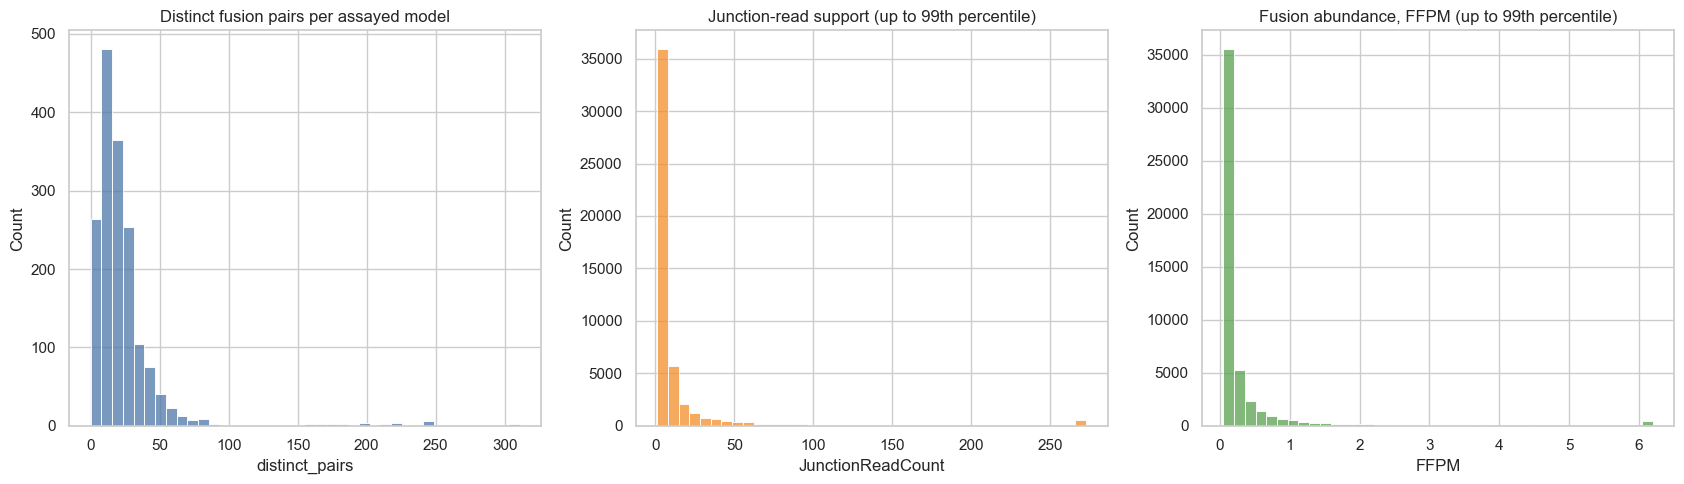

,LargeAnchorSupport,calls
0,YES_LDAS,48184
1,NO_LDAS,1824


,SpliceType,calls
0,ONLY_REF_SPLICE,26066
1,INCL_NON_REF_SPLICE,23942


In [3]:
support_columns = ['JunctionReadCount', 'SpanningFragCount', 'FFPM', 'LeftBreakEntropy', 'RightBreakEntropy', 'CCLE_count']
display(fusions[support_columns].describe().T)

calls_per_model = fusions.groupby('model_id').agg(
    filtered_calls=('FusionName', 'size'),
    distinct_pairs=('FusionName', 'nunique'),
    total_junction_reads=('JunctionReadCount', 'sum'),
).reset_index()
model_call_context = assayed.merge(calls_per_model, on='model_id', how='left', validate='one_to_one').fillna({'filtered_calls': 0, 'distinct_pairs': 0, 'total_junction_reads': 0})
display(model_call_context[['filtered_calls', 'distinct_pairs', 'total_junction_reads']].describe().T)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
sns.histplot(model_call_context['distinct_pairs'], bins=40, ax=axes[0], color='#4C78A8')
axes[0].set_title('Distinct fusion pairs per assayed model')
sns.histplot(fusions['JunctionReadCount'].clip(upper=fusions['JunctionReadCount'].quantile(0.99)), bins=40, ax=axes[1], color='#F28E2B')
axes[1].set_title('Junction-read support (up to 99th percentile)')
sns.histplot(fusions['FFPM'].clip(upper=fusions['FFPM'].quantile(0.99)), bins=40, ax=axes[2], color='#59A14F')
axes[2].set_title('Fusion abundance, FFPM (up to 99th percentile)')
plt.tight_layout(); plt.show()

display(fusions['LargeAnchorSupport'].fillna('Missing').value_counts().rename_axis('LargeAnchorSupport').reset_index(name='calls'))
display(fusions['SpliceType'].fillna('Missing').value_counts().rename_axis('SpliceType').reset_index(name='calls'))

### What this means for the project

Junction reads cross the exact fusion boundary; spanning fragments support the same event from nearby sequence. A call with both types of support is technically more reassuring than a call with almost no support. We still display the measurements instead of turning them into an unexplained confidence score.

## 3. Breakpoints and physical arrangement

A breakpoint is the physical chromosome location where normal DNA or RNA continuity changes. Fusions can join genes on different chromosomes or genes far apart on the same chromosome.

In [4]:
def breakpoint_chromosome(value):
    return str(value).split(':', 1)[0] if pd.notna(value) else np.nan

fusions = fusions.copy()
fusions['left_chromosome'] = fusions['LeftBreakpoint'].map(breakpoint_chromosome)
fusions['right_chromosome'] = fusions['RightBreakpoint'].map(breakpoint_chromosome)
fusions['chromosome_relationship'] = np.where(
    fusions['left_chromosome'].eq(fusions['right_chromosome']),
    'same chromosome',
    'different chromosomes',
)
display(fusions['chromosome_relationship'].value_counts().rename_axis('relationship').reset_index(name='calls'))

annotation_context = pd.DataFrame({
    'annotation': ['INTERCHROMOSOMAL', 'INTRACHROMOSOMAL', 'LOCAL_REARRANGEMENT', 'CCLE_StarF2019', 'TCGA_StarF2019'],
    'calls': [fusions['annots'].fillna('').str.contains(label, regex=False).sum() for label in ['INTERCHROMOSOMAL', 'INTRACHROMOSOMAL', 'LOCAL_REARRANGEMENT', 'CCLE_StarF2019', 'TCGA_StarF2019']],
})
display(annotation_context)

physical_fields = pd.DataFrame({
    'field': ['LeftBreakpoint', 'RightBreakpoint', 'strand inside breakpoint text', 'reading_frame', 'retained_protein_domains'],
    'available_in_24Q4_filtered_table': [True, True, True, False, False],
    'interpretation': [
        'Physical position of the left partner',
        'Physical position of the right partner',
        'Reported + or - orientation',
        'Cannot determine whether the joined coding sequence stays in frame',
        'Cannot determine which protein domains remain',
    ],
})
display(physical_fields)

,relationship,calls
0,different chromosomes,28078
1,same chromosome,21930


,annotation,calls
0,INTERCHROMOSOMAL,28105
1,INTRACHROMOSOMAL,21903
2,LOCAL_REARRANGEMENT,3875
3,CCLE_StarF2019,18877
4,TCGA_StarF2019,5493


,field,available_in_24Q4_filtered_table,interpretation
0,LeftBreakpoint,True,Physical position of the left partner
1,RightBreakpoint,True,Physical position of the right partner
2,strand inside breakpoint text,True,Reported + or - orientation
3,reading_frame,False,Cannot determine whether the joined coding seq...
4,retained_protein_domains,False,Cannot determine which protein domains remain


### What this means for the project

The dashboard can draw the two genes, their chromosomes, breakpoint positions, and reported direction. It cannot honestly claim that a fusion produces a working protein from this table alone, because reading-frame and retained-protein-domain fields are not present in the release-matched 24Q4 data.

## 4. Recurrent pairs, partner genes, and lineage

A recurrent fusion pair is observed in more than one model. Recurrence can strengthen interest, especially when concentrated in a biologically plausible lineage, but common technical events and passenger rearrangements still need review.

In [5]:
pair_recurrence = pair_evidence.groupby('fusion_pair_id').agg(
    models_with_pair=('model_id', 'nunique'),
    total_junction_reads=('total_junction_reads', 'sum'),
    maximum_ffpm=('max_ffpm', 'max'),
    models_with_large_anchor=('has_large_anchor_support', 'sum'),
).reset_index()
pair_recurrence['pct_of_assayed_models'] = (100 * pair_recurrence['models_with_pair'] / len(assayed)).round(3)
display(pair_recurrence.nlargest(30, 'models_with_pair'))

partners = pd.concat([
    pair_evidence[['model_id', 'gene_a_symbol']].rename(columns={'gene_a_symbol': 'gene'}),
    pair_evidence[['model_id', 'gene_b_symbol']].rename(columns={'gene_b_symbol': 'gene'}),
], ignore_index=True)
partner_summary = partners.groupby('gene').agg(models=('model_id', 'nunique'), pair_records=('model_id', 'size')).reset_index()
display(Markdown('#### Genes appearing most often as fusion partners'))
display(partner_summary.nlargest(30, 'models'))

pair_lineage = pair_evidence.merge(master[['model_id', 'oncotree_lineage']], on='model_id', how='left', validate='many_to_one')
top_pairs = pair_recurrence.nlargest(20, 'models_with_pair')['fusion_pair_id']
top_pair_lineage = pair_lineage.loc[pair_lineage['fusion_pair_id'].isin(top_pairs)].groupby(['fusion_pair_id', 'oncotree_lineage'])['model_id'].nunique().rename('models').reset_index()
display(top_pair_lineage.sort_values(['fusion_pair_id', 'models'], ascending=[True, False]))

,fusion_pair_id,models_with_pair,total_junction_reads,maximum_ffpm,models_with_large_anchor,pct_of_assayed_models
25797,RPL37--RPL37P15,325,11716,1.6414,325,19.438
9299,CAPNS1--FP236383.2,209,954,0.5969,206,12.500
16312,GAPDH--MT-ND4L,197,1073,0.3206,197,11.782
3322,AC126544.2--KANSL1,184,1356,1.3843,183,11.005
16311,GAPDH--MT-ND4,135,585,0.4734,134,8.074
27147,UBA52--UBB,132,592,0.4394,131,7.895
6427,AP000534.2--DUXAP10,120,1288,1.6687,120,7.177
6836,APP--MT-CO3,115,585,0.3786,115,6.878
23014,NCL--PTMA,114,661,0.5822,113,6.818
22059,MT-CO3--YBX1,108,501,0.2001,108,6.459


#### Genes appearing most often as fusion partners

,gene,models,pair_records
10385,MT-CO3,446,731
10391,MT-ND4L,415,794
7054,FP236383.2,391,619
7213,GAPDH,355,594
10383,MT-CO1,347,532
10390,MT-ND4,346,533
13223,RPL37,330,333
13226,RPL37P15,325,325
2148,ACTB,259,359
12468,PTMA,252,417


,fusion_pair_id,oncotree_lineage,models
13,AC126544.2--KANSL1,Lung,30
14,AC126544.2--KANSL1,Lymphoid,28
21,AC126544.2--KANSL1,Skin,16
5,AC126544.2--KANSL1,CNS/Brain,13
8,AC126544.2--KANSL1,Eye,10
...,...,...,...
401,UBA52--UBB,Thyroid,3
396,UBA52--UBB,Pancreas,2
390,UBA52--UBB,Kidney,1
398,UBA52--UBB,Pleura,1


### What this means for the project

If a pair occurs repeatedly in lung models but almost nowhere else, that lineage pattern is part of the biological explanation. The denominator remains all lung models with a fusion assay, not only the models that already have at least one fusion call.

## 5. Query examples and support sensitivity

The query uses an alphabetical pair ID so `ALK, EML4` and `EML4, ALK` return the same records. We then show the original reported orientation separately.

In [6]:
def canonical_pair(gene_a: str, gene_b: str) -> str:
    return '--'.join(sorted([gene_a.upper().strip(), gene_b.upper().strip()]))

def fusion_query(gene_a: str, gene_b: str) -> pd.DataFrame:
    pair_id = canonical_pair(gene_a, gene_b)
    result = pair_evidence.loc[pair_evidence['fusion_pair_id'].str.upper().eq(pair_id)].copy()
    return result.merge(master[['model_id', 'cell_line_name', 'oncotree_lineage']], on='model_id', how='left', validate='many_to_one')

QUERY_EXAMPLES = [('EML4', 'ALK'), ('BCR', 'ABL1'), ('TMPRSS2', 'ERG')]
query_summary = []
for gene_a, gene_b in QUERY_EXAMPLES:
    result = fusion_query(gene_a, gene_b)
    query_summary.append({
        'queried_pair': canonical_pair(gene_a, gene_b),
        'models_found': result['model_id'].nunique(),
        'lineages_found': ' | '.join(sorted(result['oncotree_lineage'].dropna().unique())),
        'total_junction_reads': result['total_junction_reads'].sum(),
        'maximum_ffpm': result['max_ffpm'].max() if len(result) else np.nan,
    })
display(pd.DataFrame(query_summary))
display(Markdown('#### EML4--ALK model-level evidence'))
display(fusion_query('ALK', 'EML4'))

support_rules = [
    ('any filtered pair call', pair_evidence['n_filtered_calls'].ge(1)),
    ('junction reads >= 2', pair_evidence['total_junction_reads'].ge(2)),
    ('junction >= 2 and spanning >= 2', pair_evidence['total_junction_reads'].ge(2) & pair_evidence['total_spanning_fragments'].ge(2)),
    ('previous rule plus large anchor', pair_evidence['total_junction_reads'].ge(2) & pair_evidence['total_spanning_fragments'].ge(2) & pair_evidence['has_large_anchor_support'].eq(1)),
]
support_sensitivity = pd.DataFrame([
    {'example_technical_support_rule': label, 'model_pair_rows_retained': int(mask.sum()), 'models_retained': pair_evidence.loc[mask, 'model_id'].nunique()}
    for label, mask in support_rules
])
display(Markdown('#### Sensitivity to example technical-support rules'))
display(support_sensitivity)

,queried_pair,models_found,lineages_found,total_junction_reads,maximum_ffpm
0,ALK--EML4,7,Bowel | Lung | Pancreas | Peripheral Nervous S...,331,2.0730
1,ABL1--BCR,24,Lymphoid | Myeloid,3768,7.9447
2,ERG--TMPRSS2,2,Prostate,413,2.5995


#### EML4--ALK model-level evidence

,model_id,gene_a_symbol,gene_b_symbol,fusion_pair_id,n_filtered_calls,total_junction_reads,total_spanning_fragments,max_ffpm,has_large_anchor_support,orientations,annotations,cell_line_name,oncotree_lineage
0,ACH-000337,ALK,EML4,ALK--EML4,1,57,58,2.0730,1,EML4->ALK,"[""Klijn_CellLines"",""GUO2018CR_TCGA"",""HaasMedCa...",NCI-H3122,Lung
1,ACH-000447,ALK,EML4,ALK--EML4,2,36,54,0.4818,1,EML4->ALK,"[""Klijn_CellLines"",""GUO2018CR_TCGA"",""HaasMedCa...",NCI-H2228,Lung
2,ACH-000933,ALK,EML4,ALK--EML4,4,31,108,0.3758,1,EML4->ALK,"[""Klijn_CellLines"",""GUO2018CR_TCGA"",""HaasMedCa...",SNU-324,Pancreas
3,ACH-001454,ALK,EML4,ALK--EML4,1,71,71,1.6628,1,EML4->ALK,"[""Klijn_CellLines"",""GUO2018CR_TCGA"",""HaasMedCa...",C10,Bowel
4,ACH-002065,ALK,EML4,ALK--EML4,2,35,72,0.6490,1,EML4->ALK,"[""Klijn_CellLines"",""GUO2018CR_TCGA"",""HaasMedCa...",HS-PSS,Peripheral Nervous System
5,ACH-002522,ALK,EML4,ALK--EML4,2,90,224,1.1472,1,EML4->ALK,"[""Klijn_CellLines"",""GUO2018CR_TCGA"",""HaasMedCa...",SNU-2292,Lung
6,ACH-002531,ALK,EML4,ALK--EML4,1,11,28,1.3203,1,EML4->ALK,"[""Klijn_CellLines"",""GUO2018CR_TCGA"",""HaasMedCa...",SNU-2535,Lung


#### Sensitivity to example technical-support rules

,example_technical_support_rule,model_pair_rows_retained,models_retained
0,any filtered pair call,39842,1670
1,junction reads >= 2,37160,1660
2,junction >= 2 and spanning >= 2,22789,1644
3,previous rule plus large anchor,22501,1640


### What this means for the project

The technical-support table shows how many records would remain under increasingly strict example rules. These are not biological truth labels. In the final dashboard, a submitted pair will show the actual reads, FFPM, anchor support, recurrence, lineages, breakpoints, and annotations so the user can see why the evidence is stronger or weaker.

## Decisions carried into feature engineering

- Use the canonical unordered `fusion_pair_id` for lookup and preserve reported orientation separately.
- Define `fusion_present=0` only for models with `has_fusion_assay=1`; otherwise keep it missing.
- Preserve call count, junction reads, spanning fragments, maximum FFPM, anchor support, breakpoints, and annotations as separate white-box features.
- Report pair recurrence by assayed-model denominator and lineage.
- Treat technical-support thresholds as sensitivity analyses, not hidden labels or proof of function.
- Do not infer reading frame, retained domains, driver status, or protein activity from fields that are not present.